In [ ]:
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive.zip


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array


In [ ]:
import zipfile
import os

zip_ref = zipfile.ZipFile("archive.zip", "r")
zip_ref.extractall("archive")
zip_ref.close()


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    "archive",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "archive",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 2022 images belonging to 1 classes.
Found 505 images belonging to 1 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE,IMG_SIZE,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
import os

for root, dirs, files in os.walk("archive"):
    level = root.replace("archive", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for f in files[:2]:
        print(f"{subindent}{f}")


archive/
    TrashType_Image_Dataset/
        glass/
            glass_169.jpg
            glass_272.jpg
        trash/
            trash_082.jpg
            trash_135.jpg
        paper/
            paper_428.jpg
            paper_405.jpg
        cardboard/
            cardboard_288.jpg
            cardboard_287.jpg
        metal/
            metal_107.jpg
            metal_004.jpg
        plastic/
            plastic_101.jpg
            plastic_349.jpg


In [ ]:
import os
import shutil

root_path = "archive"

# Auto-detect the deepest folder that contains class folders
def find_class_folder(base):
    for dirpath, dirnames, filenames in os.walk(base):
        class_folders = ['glass', 'metal', 'plastic', 'paper', 'cardboard', 'trash']
        if all(cf in dirnames for cf in class_folders):
            return dirpath
    return None

class_root = find_class_folder(root_path)

if class_root:
    print(f"Found class folders inside: {class_root}")
    for folder in os.listdir(class_root):
        src = os.path.join(class_root, folder)
        dst = os.path.join(root_path, folder)
        if os.path.isdir(src):
            shutil.move(src, dst)
    print(" Class folders moved up successfully.")
else:
    print(" Could not find expected class folders inside the dataset.")


Found class folders inside: archive/TrashType_Image_Dataset
 Class folders moved up successfully.


In [ ]:
print(os.listdir("archive"))


['TrashType_Image_Dataset', 'glass', 'trash', 'paper', 'cardboard', 'metal', 'plastic']


In [ ]:
train_generator = train_datagen.flow_from_directory(
    "archive",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "archive",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 2024 images belonging to 7 classes.
Found 503 images belonging to 7 classes.


In [ ]:
print("Classes:", train_generator.class_indices)


Classes: {'TrashType_Image_Dataset': 0, 'cardboard': 1, 'glass': 2, 'metal': 3, 'paper': 4, 'plastic': 5, 'trash': 6}


In [ ]:
import shutil

shutil.rmtree("archive/TrashType_Image_Dataset", ignore_errors=True)
print(" Removed 'TrashType_Image_Dataset' folder.")


 Removed 'TrashType_Image_Dataset' folder.


In [ ]:
train_generator = train_datagen.flow_from_directory(
    "archive",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "archive",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print(" Cleaned Classes:", train_generator.class_indices)


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
 Cleaned Classes: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.2603 - loss: 2.7601 - val_accuracy: 0.5268 - val_loss: 1.2840
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.5054 - loss: 1.2810 - val_accuracy: 0.4195 - val_loss: 1.4043
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.5748 - loss: 1.0537 - val_accuracy: 0.6143 - val_loss: 1.1898
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7353 - loss: 0.7866 - val_accuracy: 0.5765 - val_loss: 1.2396
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8252 - loss: 0.5278 - val_accuracy: 0.6302 - val_loss: 1.3082
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8849 - loss: 0.3431 - val_accuracy: 0.6123 - val_loss: 1.5813
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9317 - loss: 0.2226 - val_accuracy: 0.6004 - val_loss: 1.5848
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9462 - loss: 0.2043 - val_accuracy: 0.6123 - val_loss:

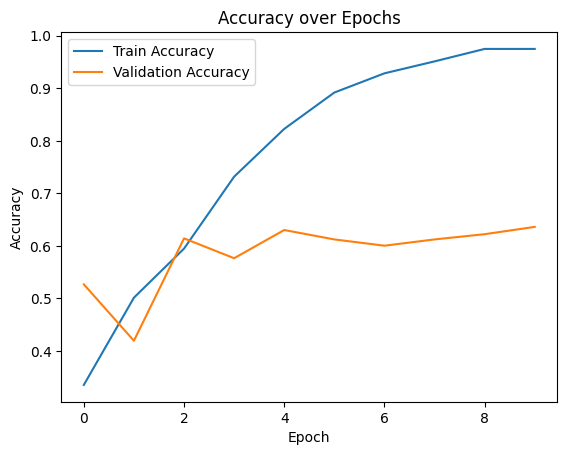

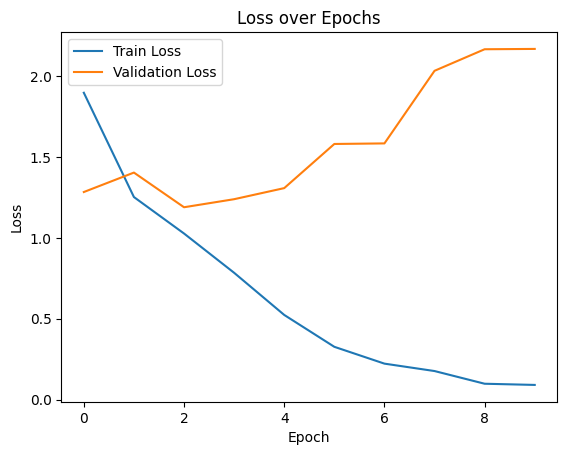

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 150
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "/content/archive",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "/content/archive",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_data, validation_data=val_data, epochs=10)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9868 - loss: 0.0614

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9868 - loss: 0.0615 - val_accuracy: 0.6302 - val_loss: 1.9321
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9827 - loss: 0.0665 - val_accuracy: 0.6441 - val_loss: 2.0914
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9857 - loss: 0.0553 - val_accuracy: 0.5964 - val_loss: 2.2072
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9633 - loss: 0.1389 - val_accuracy: 0.6064 - val_loss: 2.2345
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9852 - loss: 0.0509 - val_accuracy: 0.6243 - val_loss: 2.1884
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9904 - loss: 0.0448 - val_accuracy: 0.6302 - val_loss: 2.4311
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9950 - loss: 0.0265 - val_accuracy: 0.6322 - val_loss: 2.2597
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9969 - loss: 0.0171 - val_accuracy: 0.6183 - val_loss: 2.3751
Epo

cardboard: 403 images
glass: 501 images
metal: 410 images
paper: 594 images
plastic: 482 images
trash: 137 images


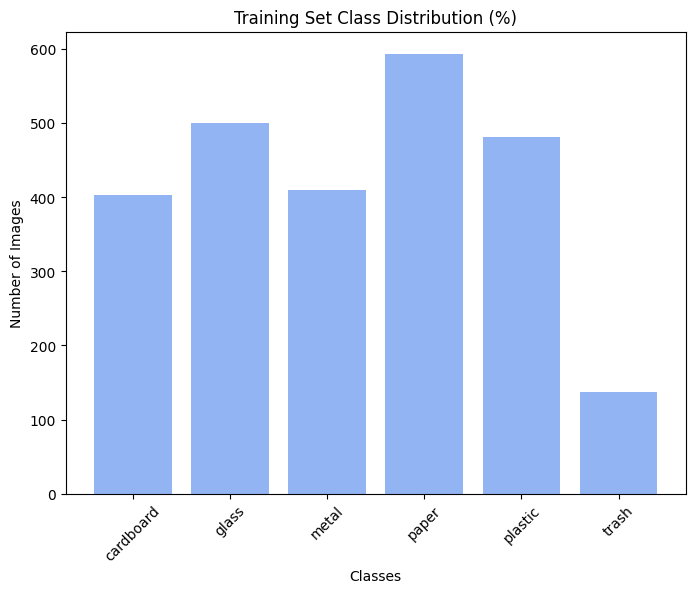

In [ ]:
import os
import matplotlib.pyplot as plt

data_dir = "/content/archive"  # change if your folder is different

# Count images per class
class_names = sorted(os.listdir(data_dir))
class_counts = []

for cls in class_names:
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        class_counts.append(count)
    else:
        print(f"Skipping non-folder: {cls}")

# Show the counts
for name, count in zip(class_names, class_counts):
    print(f"{name}: {count} images")

# Plot
plt.figure(figsize=(8,6))
plt.bar(class_names, class_counts, color='cornflowerblue', alpha=0.7)
plt.title('Training Set Class Distribution (%)')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()


In [ ]:
import os

# Replace with your extracted dataset folder
data_dir = "/content/archive"

class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
class_counts = []

for cls in class_names:
    cls_path = os.path.join(data_dir, cls)
    count = len(os.listdir(cls_path))
    class_counts.append(count)

# Print counts for checking
for cls, count in zip(class_names, class_counts):
    print(f"{cls}: {count} images")



cardboard: 403 images
glass: 501 images
metal: 410 images
paper: 594 images
plastic: 482 images
trash: 137 images


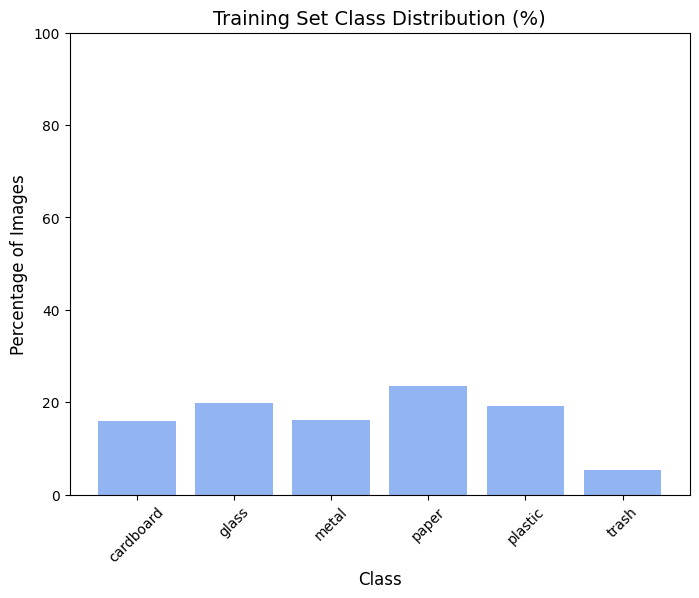

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Get true labels and predictions
# Predict on the entire validation set
val_data.reset()  # Ensure index is correct
preds = model.predict(val_data, verbose=1)

# Convert predictions and labels to class indices
y_pred = np.argmax(preds, axis=1)
y_true = val_data.classes


16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 389ms/step


In [ ]:
# Get class labels from the data generator
class_labels = list(val_data.class_indices.keys())

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving plastic-bottle.jpg to plastic-bottle.jpg


In [ ]:
print("Uploaded file(s):", list(uploaded.keys()))


Uploaded file(s): ['plastic-bottle.jpg']


In [ ]:
filename = "plastic-bottle.jpg"

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

filename = "plastic-bottle.jpg"
img = load_img(filename, target_size=(150, 150))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
class_names = list(train_generator.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]
print("Predicted Class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted Class: plastic


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Parameters
IMG_SIZE = 224
BATCH_SIZE = 32
DATASET_PATH = '/content/archive'

# ImageDataGenerator with augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Training Data
train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation Data
val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Optional: View class mappings
print(train_data.class_indices)


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,911,380 (121.73 MB)

 Trainable params: 10,637,126 (40.58 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,274,254 (81.15 MB)

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
DATASET_PATH = '/content/archive'


In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Training
train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation
val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Classes
class_labels = list(train_data.class_indices.keys())
print("Class labels:", class_labels)


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Class labels: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
from tensorflow.keras import models, layers


In [ ]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_labels), activation='softmax')
])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2718 - loss: 1.8918

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


64/64 ━━━━━━━━━━━━━━━━━━━━ 269s 4s/step - accuracy: 0.2727 - loss: 1.8882 - val_accuracy: 0.4036 - val_loss: 1.4535
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 264s 4s/step - accuracy: 0.3691 - loss: 1.4990 - val_accuracy: 0.4553 - val_loss: 1.3683
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.4643 - loss: 1.3476 - val_accuracy: 0.4493 - val_loss: 1.3374
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 266s 4s/step - accuracy: 0.4657 - loss: 1.3250 - val_accuracy: 0.4831 - val_loss: 1.3435
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 259s 4s/step - accuracy: 0.4870 - loss: 1.3012 - val_accuracy: 0.4612 - val_loss: 1.2563
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 255s 4s/step - accuracy: 0.5119 - loss: 1.2522 - val_accuracy: 0.4831 - val_loss: 1.2591
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 253s 4s/step - accuracy: 0.5176 - loss: 1.2224 - val_accuracy: 0.5308 - val_loss: 1.1541
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 266s 4s/step - accuracy: 0.5434 - loss: 1.2242 - val_accuracy: 0.5686 - val_loss: 1.

In [ ]:
loss, accuracy = model.evaluate(val_data)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")


16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.6855 - loss: 0.8681
Validation Loss: 1.0860
Validation Accuracy: 59.84%


16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step


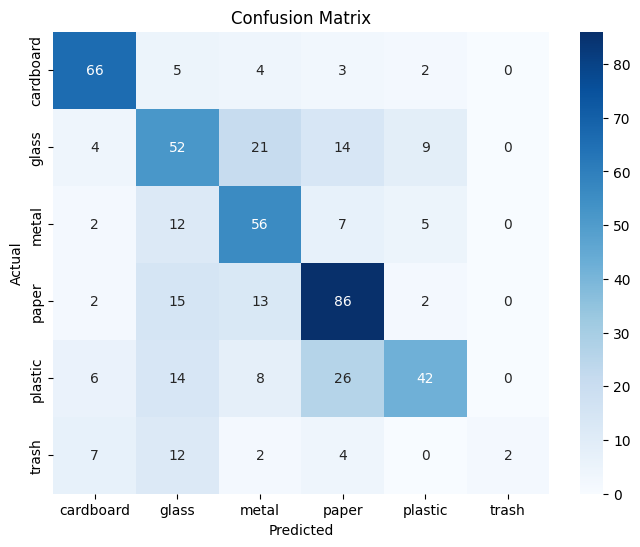

              precision    recall  f1-score   support

   cardboard       0.76      0.82      0.79        80
       glass       0.47      0.52      0.50       100
       metal       0.54      0.68      0.60        82
       paper       0.61      0.73      0.67       118
     plastic       0.70      0.44      0.54        96
       trash       1.00      0.07      0.14        27

    accuracy                           0.60       503
   macro avg       0.68      0.54      0.54       503
weighted avg       0.63      0.60      0.59       503



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
val_data.reset()
pred_probs = model.predict(val_data, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)
